In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors

from matplotlib.axes import Axes
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)
from collections import Counter

from hubo_qaoa.utils.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [3]:
def plot_hardware_dist(
    axs: list[Axes], 
    filename, copy_numbers, maxdb, maxdg, shots, 
    beta_T, eps, alpha, p = 1
) -> list[Axes]:
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
    hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
    hamiltonian = hamiltonian * norm
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/hardware/nonvariational.hardware.{filename}.error_mit.backendibm_boston.db{maxdb}.dg{maxdg}.shots{shots}.betaT{beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    sample_sequence = []
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    keys = samples_dict.keys()
    energies = res['energies']
    energies = np.array(energies)
    rescale = 1
    iters = [0, 2, 4]

    cutoff=25
    ax = axs[0]
    random_samples = np.random.choice(('0', '1'), (shots, n*T))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(norm * (evaluate_sparse_pauli_samples(rand_samples, hamiltonian)), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True, color='gray')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(1/shots, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    
    
    for i in range(1, len(axs)):
        ax = axs[i]
        rescale_value = None
        for key in keys:
            if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                rescale_value = key[1]
                break
        if rescale_value is None:
            raise Exception('Could not rescale value')
        if len(samples_dict[(p, rescale_value)]) > 3:
            counter = Counter(samples_dict[(p, rescale_value)][iters[i-1]])
        else:
            counter = Counter(samples_dict[(p, rescale_value)][i-1])
        if i == len(axs) - 1:
            print(p, counter.most_common(2))
        evals = np.round(evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)

        
        energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
        sample_vals = np.array([x for xs in energies for x in xs])
        if alpha is not None:
            quasi_sample_vals = np.sort(sample_vals)[:int(alpha * len(sample_vals))]
            sample_sequence.append(quasi_sample_vals)
        else:
            sample_sequence.append(sample_vals)
        
        ax.hist(sample_vals, bins=range(cutoff+1), weights=[1/shots]*len(sample_vals), rwidth=1, log=True, label=str(p))
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**(np.log10(1/shots)-0.1), 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1] + 1}', ha='right', va='top', transform=ax.transAxes)

    return axs

Keeping constraints at times: [0]
1 [('1110', 3213), ('1011', 125)]
Keeping constraints at times: [0 1]
1 [('000010001', 103), ('001010001', 63)]
Keeping constraints at times: [1 2 0]
1 [('110001110100', 14), ('100011110100', 13)]
Keeping constraints at times: [3 0 2 1]
1 [('101110001011100', 7), ('111110001111000', 7)]


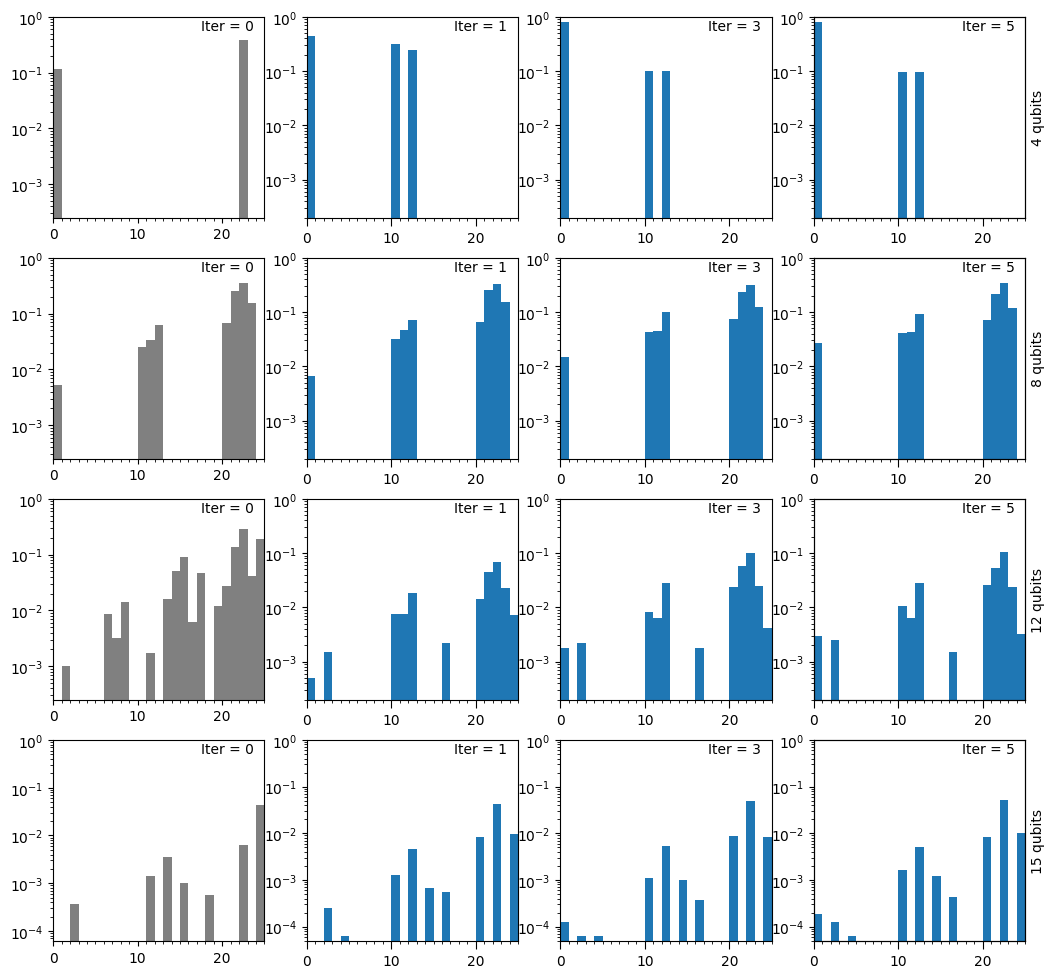

In [4]:
rows = 4
fig, axs = plt.subplots(rows, 4, figsize=(2*6.27,3*rows))
plot_hardware_dist(axs[0, :], 'test_N2_W2', [1,1], 0.75, 0.3, 4000, 0.15, 0.15, 0.1)
plot_hardware_dist(axs[1, :], 'trivial', [1,1,1], 0.75, 0.3, 4000, 0.15, 0.15, 0.1)
plot_hardware_dist(axs[2, :], 'test_N3_W4', [2,1,1], 0.75, 0.3, 4000, 0.15, 0.15, 0.1)
plot_hardware_dist(axs[3, :], 'test_N4_W5', [2,1,1,1], 0.75, 0.3, 16000, 0.15, 0.15, 0.05)
qubits = [4, 8, 12, 15, 15, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')

Keeping constraints at times: [0 2 3 1]
1 [('000110000010001', 4), ('001100111010001', 3)]
Keeping constraints at times: [0 1 2 3]
1 [('011000000100001', 4), ('010101101001011', 4)]
Keeping constraints at times: [1 2 0 3]
1 [('101110001011100', 7), ('111110001111000', 7)]
Keeping constraints at times: [2 3 1 0]
1 [('010010101110110', 3), ('001100011010010', 3)]


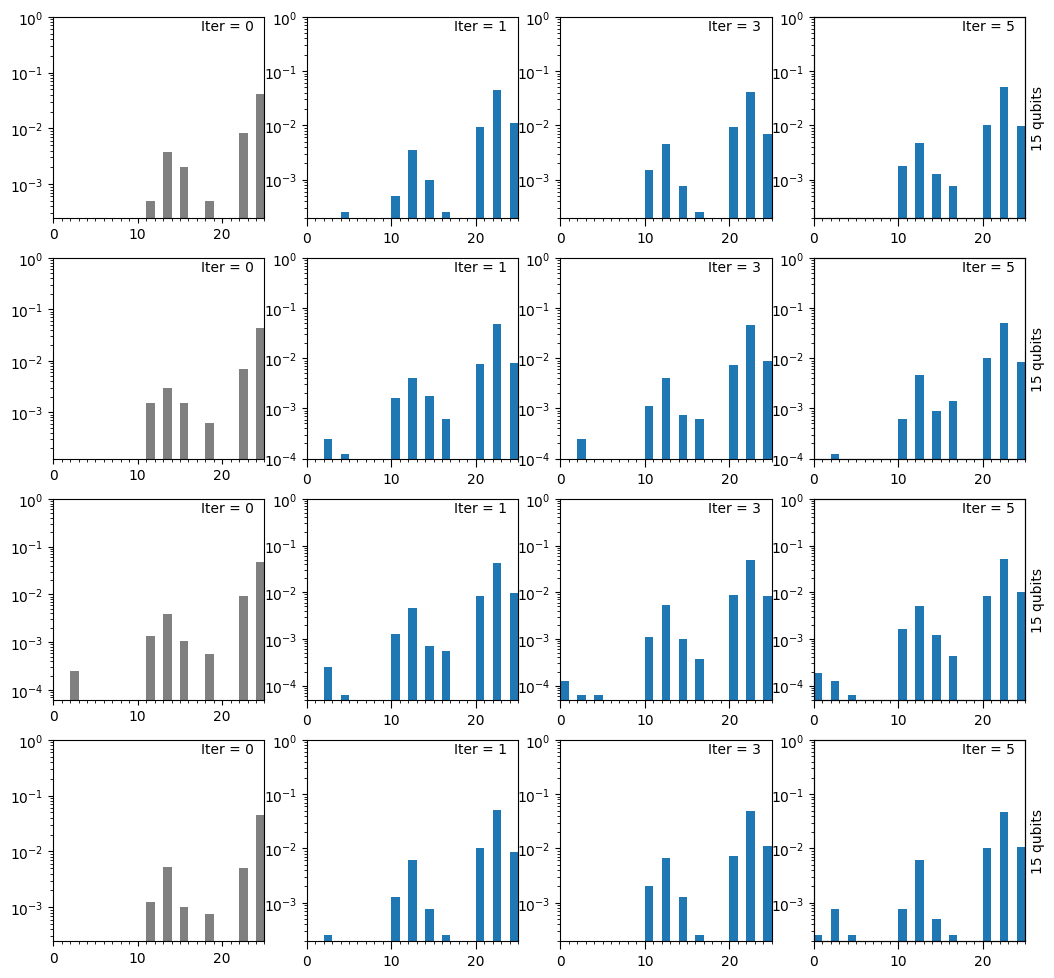

In [5]:
rows = 4
fig, axs = plt.subplots(rows, 4, figsize=(2*6.27,3*rows))
plot_hardware_dist(axs[0, :], 'test_N4_W5', [2,1,1,1], 0.75, 0.3, 4000, 0.15, 0.15, 0.1)
plot_hardware_dist(axs[1, :], 'test_N4_W5', [2,1,1,1], 0.75, 0.3, 8000, 0.15, 0.15, 0.05)
plot_hardware_dist(axs[2, :], 'test_N4_W5', [2,1,1,1], 0.75, 0.3, 16000, 0.15, 0.15, 0.05)
plot_hardware_dist(axs[3, :], 'test_N4_W5', [2,1,1,1], 0.75, 0.3, 4000, 0.25, 0.25, 0.1)
qubits = [15, 15, 15, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')

In [6]:
2**15

32768

In [2]:
filename, maxdb, maxdg, shots, beta_T, eps, alpha = 'test_N4_W5', 0.75, 0.3, 8000, 0.25, 0.25, 0.05
with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/hardware/nonvariational.hardware.{filename}.error_mit.backendibm_boston.db{maxdb}.dg{maxdg}.shots{shots}.betaT{beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
    res = pickle.load(f)

In [4]:
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
copy_numbers = [2,1,1,1]
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm

Keeping constraints at times: [1 2 0 3]


In [13]:
samples = res['samples_dict'][(1,1)][3]
sum(np.round(evaluate_sparse_pauli_samples(samples, hamiltonian)) == 0)

np.int64(1)

In [3]:
res.keys()

dict_keys(['energies', 'delta_b_fixed', 'delta_g_fixed', 'ps', 'rescaling', 'samples_dict', 'angles_dict'])

In [9]:
from collections import Counter
print(Counter(res['samples_dict'][(1,1)][0]).most_common(10))
print(Counter(res['samples_dict'][(1,1)][-1]).most_common(10))

[('111101011000000', 7), ('111101110000001', 5), ('111110101010100', 5), ('001111010001000', 5), ('111101010010001', 5), ('011010001010110', 5), ('111010111101101', 5), ('101100111100110', 5), ('111101111101010', 5), ('111111101110100', 4)]
[('101110001011100', 7), ('111110001111000', 7), ('111110001000011', 6), ('011100001110100', 6), ('111111000011101', 6), ('011110001110111', 6), ('110110000110010', 6), ('011100001110010', 6), ('111110101110101', 5), ('100001001001010', 5)]


In [10]:
2**15

32768

Keeping constraints at times: [2 3 0 1]
0
[2. 2. 2. 2. 4.] [0.24007816 0.24007816 0.24007816 0.24007816 0.03968465]
[22. 22. 22. 22. 22.] [1.29166522e-32 1.29166522e-32 1.29166522e-32 1.29166522e-32
 1.29166522e-32]
[1.07563572e-06 2.79763895e-01 3.96863996e-02 7.59920489e-01
 1.20817869e-06 7.20236103e-01 2.40079376e-01 7.20235298e-01
 2.79764029e-01 9.40543801e-07 2.79763625e-01 3.96862671e-02
 7.59919957e-01 1.47872585e-06 7.20235971e-01]

1
[ 2.  4.  4. 10. 10.] [7.51534007e-01 1.24227736e-01 1.24227736e-01 4.18897817e-07
 4.18897817e-07]
[22. 22. 22. 22. 22.] [4.04339286e-32 4.04339286e-32 4.04339286e-32 4.04339286e-32
 4.04339286e-32]
[1.24230690e-01 1.24231533e-01 2.48459265e-01 8.75768045e-01
 1.24230681e-01 7.51539893e-01 2.95451048e-06 7.51538630e-01
 1.24232370e-01 1.24231097e-01 1.24230687e-01 2.48461363e-01
 8.75767222e-01 1.24234461e-01 7.51540740e-01]

2
[-7.10542736e-15 -7.10542736e-15  2.00000000e+00  4.00000000e+00
  1.00000000e+01] [3.78854590e-01 3.78854590e-01 2.07

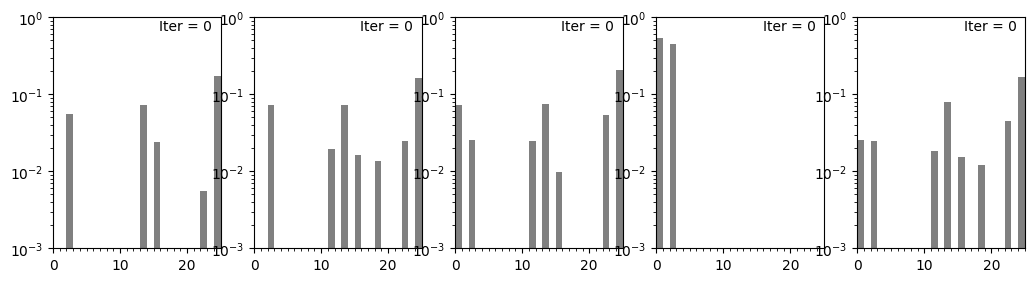

In [11]:
from hubo_qaoa.utils.iterative_qaoa_utils import _subsample, _get_biases, _boltzmann
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
copy_numbers = [2,1,1,1]
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm
fig, axs = plt.subplots(1,5, figsize=(2*6.27, 3))
cutoff=25
shots=40000
for i in range(5):
    ax = axs[i]
    samples = res['samples_dict'][(1,1)][i]
    energies = evaluate_sparse_pauli_samples(samples, hamiltonian)
    energies = np.array(energies)
    subsamples, subenergies = _subsample(samples, energies, alpha)
    biases = _get_biases(subsamples, subenergies, beta_T)
    probabilities = 0.5 * (1 - biases)
    print(i)
    boltzmann = _boltzmann(subenergies, beta_T)
    print(subenergies[:5], boltzmann[:5])
    print(subenergies[-5:], boltzmann[-5:])
    print(probabilities)
    print()
    random_samples =[np.random.choice(('0', '1'), (shots,), p=(1-probabilities[i], probabilities[i])) for i in range(n*T)]
    random_samples = [''.join([random_samples[i][j] for i in range(n*T)][::-1]) for j in range(shots)]
    rand_vals = np.round(norm * (evaluate_sparse_pauli_samples(random_samples, hamiltonian)), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True, color='gray')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)

In [12]:
filename, maxdb, maxdg, shots, beta_T, eps, alpha = 'test_N4_W5', 0.75, 0.3, 16000, 0.15, 0.15, 0.05
with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.ps5.shots{shots}.betaT{beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
    res = pickle.load(f)

In [13]:
res.keys()

dict_keys(['energies', 'delta_b_fixed', 'delta_g_fixed', 'ps', 'rescaling', 'samples_dict'])

Keeping constraints at times: [2 3 0 1]
0
[-7.10542736e-15 -7.10542736e-15 -7.10542736e-15 -7.10542736e-15
 -7.10542736e-15] [0.01566204 0.01566204 0.01566204 0.01566204 0.01566204]
[12. 12. 12. 12. 12.] [6.51759739e-12 6.51759739e-12 6.51759739e-12 6.51759739e-12
 6.51759739e-12]
[0.62084114 0.84290362 0.13685193 0.04852062 0.11411849 0.13294206
 0.91013397 0.04297796 0.86009487 0.0413461  0.84290406 0.13685179
 0.09550634 0.11411833 0.13294139]

2
[-7.10542736e-15 -7.10542736e-15 -7.10542736e-15 -7.10542736e-15
 -7.10542736e-15] [0.00125 0.00125 0.00125 0.00125 0.00125]
[-7.10542736e-15 -7.10542736e-15 -7.10542736e-15 -7.10542736e-15
 -7.10542736e-15] [0.00125 0.00125 0.00125 0.00125 0.00125]
[1.00000000e+00 1.00000000e+00 7.88258347e-15 7.88258347e-15
 7.88258347e-15 7.88258347e-15 1.00000000e+00 7.88258347e-15
 1.00000000e+00 7.88258347e-15 1.00000000e+00 7.88258347e-15
 7.88258347e-15 7.88258347e-15 7.88258347e-15]

4
[-7.10542736e-15 -7.10542736e-15 -7.10542736e-15 -7.10542736e-1

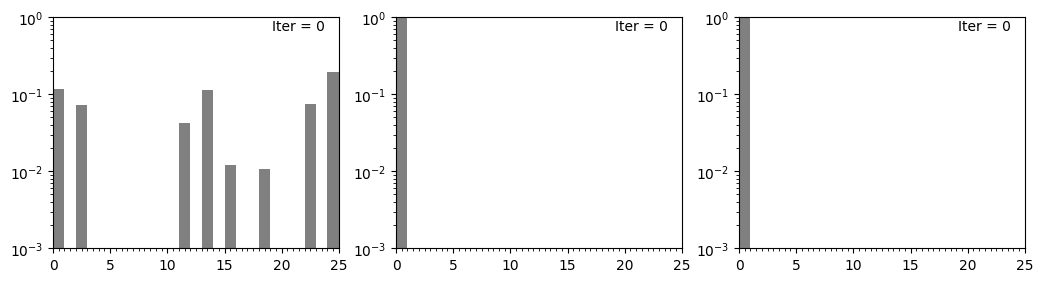

In [14]:
from hubo_qaoa.utils.iterative_qaoa_utils import _subsample, _get_biases, _boltzmann
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
copy_numbers = [2,1,1,1]
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm
fig, axs = plt.subplots(1,3, figsize=(2*6.27, 3))
cutoff=25
shots=40000
for idx, i in enumerate(range(0,5,2)):
    ax = axs[idx]
    samples = res['samples_dict'][(1,1)][i]
    energies = evaluate_sparse_pauli_samples(samples, hamiltonian)
    energies = np.array(energies)
    subsamples, subenergies = _subsample(samples, energies, alpha)
    biases = _get_biases(subsamples, subenergies, beta_T)
    probabilities = 0.5 * (1 - biases)
    print(i)
    boltzmann = _boltzmann(subenergies, beta_T)
    print(subenergies[:5], boltzmann[:5])
    print(subenergies[-5:], boltzmann[-5:])
    print(probabilities)
    print()
    random_samples =[np.random.choice(('0', '1'), (shots,), p=(1-probabilities[i], probabilities[i])) for i in range(n*T)]
    random_samples = [''.join([random_samples[i][j] for i in range(n*T)][::-1]) for j in range(shots)]
    rand_vals = np.round(norm * (evaluate_sparse_pauli_samples(random_samples, hamiltonian)), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True, color='gray')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)